In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../input/titanic/train.csv')
test = pd.read_csv('../input/titanic/test.csv')

In [3]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.0+ KB


In [4]:
df.shape

(891, 12)

In [5]:
df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Text(0.5, 1.0, 'Missing Age by Gender')

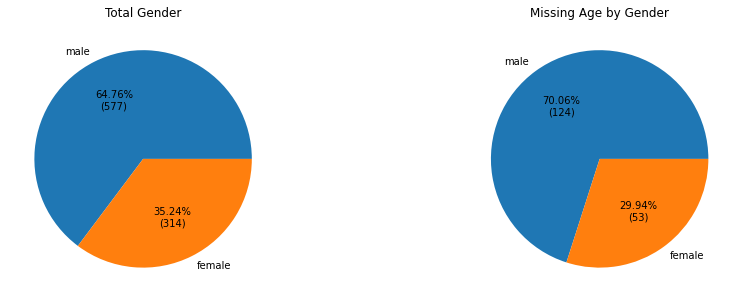

In [7]:
plt.figure(figsize=(15,5))
plt.subplot(121)
df['Sex'].value_counts().plot(kind='pie',autopct=lambda p:'{:.2f}%\n({:.0f})'.format(p,(p/100)*(891)))
plt.ylabel('')
plt.title('Total Gender')

plt.subplot(122)
df[df['Age'].isna()]['Sex'].value_counts().plot(kind='pie',autopct=lambda p:'{:.2f}%\n({:.0f})'.format(p,(p/100)*(177)))
plt.ylabel('')
plt.title('Missing Age by Gender')

/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


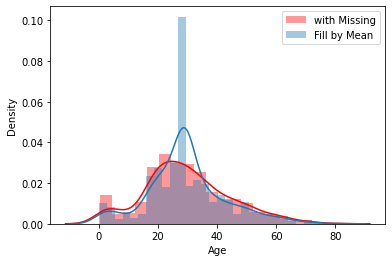

In [8]:
sns.distplot(df['Age'],color='r',label='with Missing')
sns.distplot(df['Age'].fillna(df['Age'].mean()).astype(int),label='Fill by Mean')
plt.legend()

In [9]:
df['Age'].fillna(df['Age'].mean(),inplace=True)
test['Age'].fillna(test['Age'].mean(),inplace=True)

In [10]:
def detect_person(data):
    if 'Mr.' in data: return 3
    elif 'Miss.' in data : return 2 
    elif 'Mrs.' in data: return 1
    else: return 0

In [11]:
df['person_type']=df['Name'].apply(detect_person)
test['person_type']=test['Name'].apply(detect_person)

In [12]:
df.drop(columns='Name',inplace=True)
test.drop(columns='Name',inplace=True)

In [13]:
df['Sex']=df['Sex'].apply(lambda x: 1 if x=='male' else 0)
test['Sex']=test['Sex'].apply(lambda x: 1 if x=='male' else 0)

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


<AxesSubplot:xlabel='Age'>

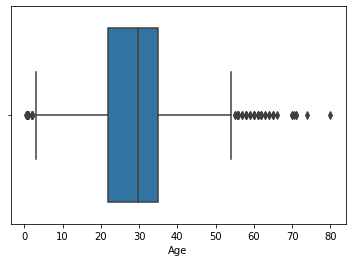

In [14]:
sns.boxplot(df['Age'])

In [15]:
# outlier detection
def outliers_detect(data):
    q1=data.quantile(0.25)
    q3=data.quantile(0.75)
#     print(q1,q3)
    iqr = q3-q1
    lower_value = q1-1.5*iqr
    upper_value = q3+1.5*iqr
    return lower_value,upper_value


In [16]:
low,high = outliers_detect(df['Age'])
low,high

(2.5, 54.5)

In [17]:
df['Age']=df['Age'].apply(lambda x: low if x<low else(high if x > high else x)).astype(int)
test['Age']=test['Age'].apply(lambda x: low if x<low else(high if x > high else x)).astype(int)

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


<AxesSubplot:xlabel='Age'>

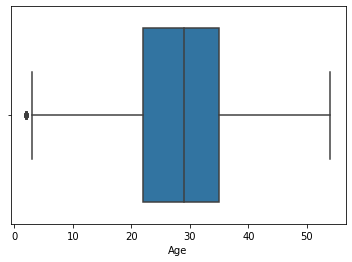

In [18]:
sns.boxplot(df['Age'])

/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='Age', ylabel='Density'>

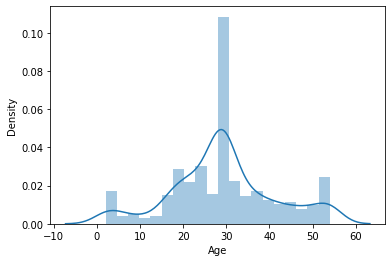

In [19]:
sns.distplot(df['Age'])

In [20]:
df['Family']=df['SibSp']+df['Parch']+1
test['Family']=test['SibSp']+df['Parch']+1

In [21]:
df.drop(columns=['SibSp','Parch','Ticket','Cabin'],inplace=True)
test.drop(columns=['SibSp','Parch','Ticket','Cabin'],inplace=True)

/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='Fare', ylabel='Density'>

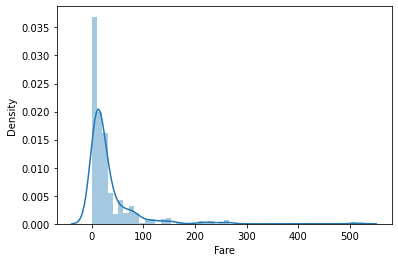

In [22]:
sns.distplot(df['Fare'])

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


<AxesSubplot:xlabel='Fare'>

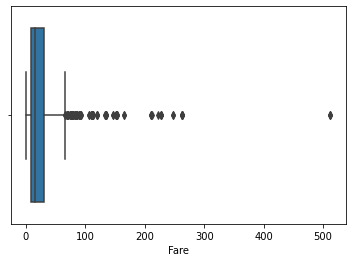

In [23]:
sns.boxplot(df['Fare'])

In [24]:
low_fare,high_fare=outliers_detect(df['Fare'])

In [25]:
df['Fare']=df['Fare'].apply(lambda x: low_fare if x<low_fare else(high_fare if x > high_fare else x))
test['Fare']=test['Fare'].apply(lambda x: low_fare if x<low_fare else(high_fare if x > high_fare else x))

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


<AxesSubplot:xlabel='Fare'>

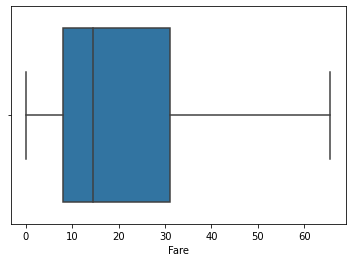

In [26]:
sns.boxplot(df['Fare'])

/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='Fare', ylabel='Density'>

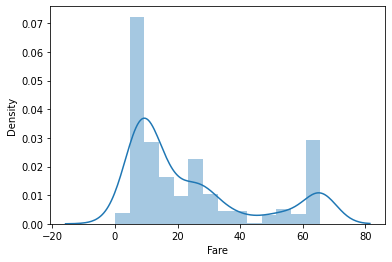

In [27]:
sns.distplot(df['Fare'])

In [28]:
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])
test['Embarked']=test['Embarked'].fillna(df['Embarked'].mode()[0])
test['Fare'].fillna(test['Fare'].mean(),inplace=True)

In [29]:
df['Embarked']=df['Embarked'].apply(lambda x: 2 if x=='C' else(1 if x=='S' else 0))
test['Embarked']=test['Embarked'].apply(lambda x: 2 if x=='C' else(1 if x=='S' else 0))

In [30]:
df.drop(columns='PassengerId',inplace=True)
test2=test.iloc[:,1:]

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Survived     891 non-null    int64  
 1   Pclass       891 non-null    int64  
 2   Sex          891 non-null    int64  
 3   Age          891 non-null    int64  
 4   Fare         891 non-null    float64
 5   Embarked     891 non-null    int64  
 6   person_type  891 non-null    int64  
 7   Family       891 non-null    int64  
dtypes: float64(1), int64(7)
memory usage: 55.8 KB


In [32]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Sex          418 non-null    int64  
 3   Age          418 non-null    int64  
 4   Fare         418 non-null    float64
 5   Embarked     418 non-null    int64  
 6   person_type  418 non-null    int64  
 7   Family       418 non-null    float64
dtypes: float64(2), int64(6)
memory usage: 26.2 KB


In [33]:
df

,Survived,Pclass,Sex,Age,Fare,Embarked,person_type,Family
0,0,3,1,22,7.2500,1,3,2
1,1,1,0,38,65.6344,2,1,2
2,1,3,0,26,7.9250,1,2,1
3,1,1,0,35,53.1000,1,1,2
4,0,3,1,35,8.0500,1,3,1
...,...,...,...,...,...,...,...,...
886,0,2,1,27,13.0000,1,0,1
887,1,1,0,19,30.0000,1,2,1
888,0,3,0,29,23.4500,1,2,4
889,1,1,1,26,30.0000,2,3,1


In [34]:
from sklearn.preprocessing import StandardScaler 

In [35]:
scaler = StandardScaler()

In [36]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [37]:
from sklearn.model_selection import train_test_split

In [38]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

In [39]:
scaler.fit(X_train)

StandardScaler()

In [40]:
X_train_scaler = scaler.fit_transform(X_train)
X_test_scaler = scaler.fit_transform(X_test)

In [41]:
from sklearn.linear_model import LogisticRegression

In [42]:
lor = LogisticRegression()
lor2= LogisticRegression()

In [43]:
lor.fit(X_train,y_train)
lor2.fit(X_train_scaler,y_train)

LogisticRegression()

In [44]:
y_pred=lor.predict(X_test)
y_pred2 = lor2.predict(X_test)

/opt/conda/lib/python3.7/site-packages/sklearn/base.py:439: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  f"X has feature names, but {self.__class__.__name__} was fitted without"


In [45]:
from sklearn.metrics import accuracy_score

In [46]:
accuracy_score(y_test,y_pred)

0.7932960893854749

In [47]:
accuracy_score(y_test,y_pred2)

0.6759776536312849

In [48]:
from sklearn.tree import DecisionTreeClassifier

In [49]:
dtc = DecisionTreeClassifier()

In [50]:
dtc.fit(X_train,y_train)

DecisionTreeClassifier()

In [51]:
dtc_pred = dtc.predict(X_test)

In [52]:
accuracy_score(y_test,dtc_pred)

0.7541899441340782

In [53]:
from sklearn.ensemble import RandomForestClassifier

In [54]:
rfc = RandomForestClassifier()

In [55]:
rfc.fit(X_train,y_train)

RandomForestClassifier()

In [56]:
rfc_pred=rfc.predict(X_test)

In [57]:
accuracy_score(y_test,rfc_pred)

0.8044692737430168

In [58]:
from sklearn.svm import SVC

In [59]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
k_fold = KFold(n_splits=10, shuffle=True, random_state=0)

In [60]:
clf = SVC()
scoring = 'accuracy'
score = cross_val_score(clf, X_train, y_train, cv=k_fold, n_jobs=1, scoring=scoring)
print(score)

[0.68055556 0.77777778 0.69014085 0.69014085 0.61971831 0.69014085
 0.76056338 0.71830986 0.63380282 0.63380282]


In [61]:
round(np.mean(score)*100,2)

68.95

In [62]:
pred=lor.predict(test2)

In [63]:
submission = pd.DataFrame({
        "PassengerId": test["PassengerId"],
        "Survived": pred
    })

In [64]:
submission

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [65]:
submission.to_csv('submission.csv')